## Introdução

O conjunto de dados de acidentes de trânsito, disponibilizado pela Polícia Rodoviária Federal (PRF) por meio do portal de dados abertos, reúne informações detalhadas sobre ocorrências em rodovias federais brasileiras. Esses dados são fundamentais para o monitoramento da segurança viária, planejamento de políticas públicas e análise de fatores associados à gravidade dos acidentes.

A natureza dessas informações permite a aplicação de métodos de aprendizado de máquina adequados para problemas de classificação, com destaque para o Random Forest, que possibilita investigar fatores associados à ocorrência de óbitos em acidentes de trânsito.

## O Banco de Dados

O banco de dados contém registros de acidentes de trânsito ocorridos no estado da Paraíba, contemplando variáveis relacionadas às características dos envolvidos e às condições do acidente, como sexo, tipo de envolvido, tipo de acidente, condição meteorológica, fase do dia e estado físico.

Essa estrutura possibilita a análise da ocorrência de óbitos nos acidentes, bem como a investigação de padrões associados a fatores comportamentais, ambientais e circunstanciais presentes no momento do sinistro.

## Modelagem Estatística (Random Forest)

A variável resposta principal — ocorrência de óbito — é caracterizada como uma variável binária, assumindo valores 0 (não óbito) e 1 (óbito). Nesse contexto, a análise é conduzida por meio do Random Forest, um método de aprendizado de máquina baseado em conjuntos de árvores de decisão, permitindo modelar a relação entre a variável resposta e um conjunto de covariáveis explicativas, como sexo, tipo de envolvido, tipo de acidente, condição meteorológica, fase do dia e estado físico.

O Random Forest estima a probabilidade de ocorrência de óbito por meio da agregação das predições de múltiplas árvores de decisão treinadas em amostras bootstrap do conjunto de dados, sendo amplamente utilizado em situações onde o interesse está na classificação de eventos binários com alta acurácia preditiva. Além disso, o modelo possibilita a interpretação da relevância das variáveis por meio das medidas de importância das variáveis (*feature importance*), como a diminuição média da impureza de Gini e a diminuição média da acurácia, permitindo identificar os fatores de maior contribuição para a predição dos acidentes fatais.

Essa abordagem possibilita a identificação de padrões relevantes e a avaliação do impacto das variáveis explicativas na probabilidade de ocorrência de óbitos, contribuindo para análises voltadas à segurança no trânsito.

In [10]:

# Random Forest — Análise de Acidentes de Trânsito (PRF / Paraíba)
# =============================================================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

df = pd.read_excel("acidentes2026_PB.xlsx")
df = df.dropna(how = 'all')
df.head()

,pesid,data_inversa,dia_semana,horario,br,km,municipio,causa_acidente,tipo_acidente,Unnamed: 9,...,tipo_envolvido,estado_fisico,idade,sexo,ilesos,feridos_leves,feridos_graves,mortos,latitude,longitude
0,1663875,2026-01-01,quinta-feira,04:04:00,153,155.0,ARAGUAINA,Objeto estático sobre o leito carroçável,Tombamento,NaN,...,Condutor,Ileso,57,Masculino,1,0,0,0,-7.291548,-48.286252
1,1663872,2026-01-01,quinta-feira,06:40:00,262,146.1,RIO CASCA,Condutor Dormindo,Colisão frontal,NaN,...,Condutor,Ileso,45,Masculino,1,0,0,0,-20.024073,-42.742229
2,1663827,2026-01-01,quinta-feira,06:58:00,101,193.0,BIGUACU,Reação tardia ou ineficiente do condutor,Colisão lateral mesmo sentido,NaN,...,Condutor,Ileso,50,Masculino,1,0,0,0,-27.489352,-48.655658
3,1663828,2026-01-01,quinta-feira,07:05:00,60,23.0,BRASILIA,Reação tardia ou ineficiente do condutor,Colisão traseira,NaN,...,Condutor,Ileso,69,Masculino,1,0,0,0,-15.988927,-48.226300
4,1663884,2026-01-01,quinta-feira,06:17:00,163,1044.0,MATUPA,Transitar na contramão,Colisão frontal,NaN,...,Condutor,Ileso,40,Masculino,1,0,0,0,-10.143306,-54.930756


Os dados apresentados na tabela a seguir descrevem as variáveis disponíveis no conjunto de dados de acidentes de trânsito da Polícia Rodoviária Federal (PRF) para o estado da Paraíba. Cada variável possui uma classificação quanto ao tipo de dado, natureza e seu uso potencial em análises baseadas em modelos de classificação, como a Random forest. Essas informações são essenciais para compreender a estrutura do banco de dados e orientar as análises subsequentes.

| Variável                   | Tipo de dado       | Natureza    | Característica                                                                                                                     |
| -------------------------- | ------------------ | ----------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| **sexo**                   | Categórica nominal | Qualitativa | Sexo do envolvido no acidente; pode indicar diferenças de comportamento e risco entre grupos                                       |
| **tipo_envolvido**         | Categórica nominal | Qualitativa | Classificação do envolvido (condutor, passageiro, pedestre, etc.); relevante para identificar perfis de maior vulnerabilidade      |
| **tipo_acidente**          | Categórica nominal | Qualitativa | Tipo de ocorrência (colisão, atropelamento, capotamento, etc.); variável fundamental para caracterização do evento                 |
| **condicao_metereologica** | Categórica nominal | Qualitativa | Condições climáticas no momento do acidente (chuva, céu claro, neblina, etc.); influencia a probabilidade de acidentes mais graves |
| **fase_dia**               | Categórica nominal | Qualitativa | Período do dia (dia, noite, amanhecer, entardecer); pode estar associado à visibilidade e risco de ocorrência                      |
| **estado_fisico**          | Categórica nominal | Qualitativa | Condição física do envolvido após o acidente (ileso, ferido leve, grave, etc.); importante para caracterizar a severidade          |
| **classificacao_acidente** | Categórica nominal | Qualitativa | Classificação geral do acidente quanto à gravidade; pode ser utilizada em análises de classificação multiclasse                    |
| **morte**                  | Binária (0/1)      | Qualitativa | Indica ocorrência de óbito (1 = sim, 0 = não); variável resposta principal em modelos de Regressão Logística                       |

---


In [3]:
from sklearn.preprocessing import OrdinalEncoder
# # Pega as 2 maiores categorias, resto vira Other
# freq = df['causa_acidente'].value_counts(normalize=True)
# top2 = freq.nlargest(2).index

# df['causa_acidente_grupo'] = df['causa_acidente'].apply(
#     lambda x: x if x in top2 else 'Other'
# )

# Variáveis explicativas
cols_X = [
    "sexo",
    "tipo_envolvido",
    "condicao_metereologica",
    "fase_dia",
    "uso_solo",
    "tipo_pista",
]

# Variável resposta
col_y = "classificacao_acidente"

# Criar base
df_modelo = df[cols_X + [col_y]].copy()

# Separar X
X = df_modelo[cols_X]

# Aplicar encoding (em TODAS categóricas) e Converter de volta para DataFrame

encoder = OrdinalEncoder()
X = encoder.fit_transform(X)
X = pd.DataFrame(X, columns=cols_X)
X = X.astype("category")

# Atualizar no df_modelo
df_modelo[cols_X] = X
df_modelo = df_modelo.dropna()
df_modelo.head(10)

,sexo,tipo_envolvido,condicao_metereologica,fase_dia,uso_solo,tipo_pista,classificacao_acidente
1,2.0,1.0,1.0,3.0,0.0,2.0,Com Vítimas Feridas
2,2.0,1.0,5.0,0.0,1.0,0.0,Com Vítimas Feridas
3,2.0,1.0,1.0,3.0,0.0,0.0,Com Vítimas Feridas
4,2.0,1.0,6.0,0.0,0.0,2.0,Com Vítimas Feridas
5,2.0,1.0,1.0,3.0,0.0,0.0,Com Vítimas Feridas
6,2.0,2.0,0.0,3.0,0.0,2.0,Com Vítimas Feridas
7,2.0,1.0,0.0,3.0,0.0,2.0,Com Vítimas Feridas
8,2.0,1.0,5.0,3.0,0.0,2.0,Sem Vítimas
9,2.0,1.0,1.0,3.0,0.0,2.0,Sem Vítimas
10,3.0,1.0,6.0,3.0,1.0,2.0,Com Vítimas Feridas


## dividino a base para as variáveis preditoras

In [4]:
X = df_modelo.drop("classificacao_acidente", axis=1); X = X.dropna()
y = df_modelo["classificacao_acidente"]; y = y.dropna()


Inicialmente, foi realizada a divisão da base de dados, separando as variáveis preditoras da variável resposta. Esse procedimento é fundamental para a construção dos modelos, pois permite utilizar as informações explicativas de forma estruturada na etapa de treinamento e avaliação.Inicialmente, foi realizada a divisão da base de dados, separando as variáveis preditoras da variável resposta. Esse procedimento é fundamental para a construção dos modelos, pois permite utilizar as informações explicativas de forma estruturada na etapa de treinamento e avaliação.

## treino e teste 

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

Posteriormente, a base de dados foi dividida em conjuntos de treino e teste. O conjunto de treino foi utilizado para ajustar o modelo, enquanto o conjunto de teste foi reservado para avaliar seu desempenho em dados não observados, permitindo uma análise mais realista da capacidade de generalização do modelo.

## treinando o Random Forest

In [7]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## Avalaliando o RF

In [20]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)

print(classification_report(y_test, y_pred))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro"), 4))

                     precision    recall  f1-score   support

 Com Vítimas Fatais       0.20      0.63      0.30       431
Com Vítimas Feridas       0.86      0.40      0.55      3582
        Sem Vítimas       0.17      0.48      0.25       529

           accuracy                           0.43      4542
          macro avg       0.41      0.50      0.37      4542
       weighted avg       0.72      0.43      0.49      4542

AUC-ROC: 0.6806


O modelo foi avaliado sobre 4.542 registros de teste, com três classes: **Com Vítimas Fatais**, **Com Vítimas Feridas** e **Sem Vítimas**. O AUC-ROC de **0.68** indica capacidade discriminativa moderada, considerando a complexidade do problema multiclasse.

**Acurácia geral de 43%** não deve ser interpretada isoladamente, pois a classe "Com Vítimas Feridas" concentra 79% dos dados (3.582 de 4.542 registros) — um desbalanceamento severo que penaliza artificialmente a acurácia global.

**Com Vítimas Feridas** foi a classe mais bem aprendida, com precisão de 86% — o modelo raramente classifica erroneamente outro caso como ferido. Porém o recall de 40% revela que ele perde mais da metade dos acidentes com feridos reais, classificando-os nas outras categorias.

**Com Vítimas Fatais** apresentou o padrão inverso: recall de 63% significa que o modelo consegue identificar a maioria dos acidentes fatais, mas com precisão de apenas 20% — ou seja, para cada acidente fatal corretamente identificado, há quatro falsos alarmes. Para aplicações de segurança viária, esse comportamento pode ser preferível a perder casos fatais.

**Sem Vítimas** teve desempenho fraco nas duas métricas, sugerindo que as variáveis disponíveis não conseguem distinguir bem acidentes sem vítimas dos demais — possivelmente porque esse desfecho depende de fatores não capturados no modelo, como velocidade ou uso de cinto.

O **F1-score macro de 0.37** confirma que o modelo tem dificuldade em equilibrar desempenho entre as três classes simultaneamente, o que é esperado dado o forte desbalanceamento. 

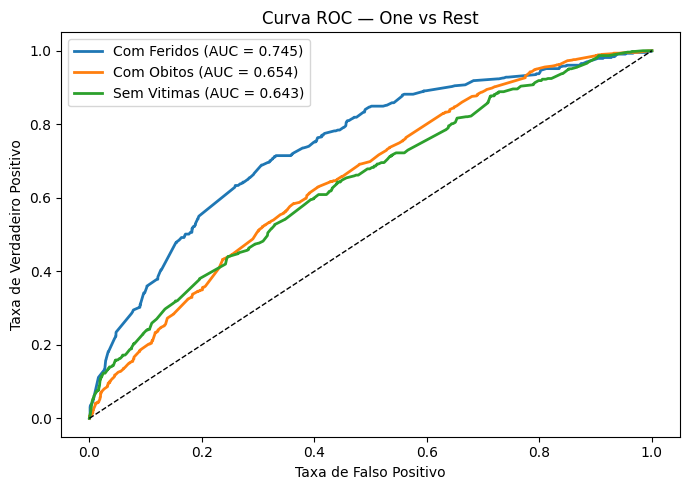

In [21]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binariza y_test para OvR
y_bin = label_binarize(y_test, classes=rf.classes_)
nomes = ["Com Feridos", "Com Obitos", "Sem Vitimas"]

fig, ax = plt.subplots(figsize=(7, 5))

for i, nome in enumerate(nomes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, lw=2, label=f"{nome} (AUC = {auc(fpr, tpr):.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("Taxa de Falso Positivo")
ax.set_ylabel("Taxa de Verdadeiro Positivo")
ax.set_title("Curva ROC — One vs Rest")
ax.legend()
plt.tight_layout()
plt.show()

O gráfico apresenta as curvas ROC para cada classe no esquema One-vs-Rest

**Com Feridos (AUC = 0.745)** foi a classe mais bem discriminada pelo modelo. Faz sentido: é a classe majoritária nos dados originais, com padrões mais consolidados e diversificados para o modelo aprender.

**Com Óbitos (AUC = 0.654)** teve desempenho intermediário. O modelo consegue separar acidentes fatais dos demais melhor que o acaso, mas com limitações — possivelmente porque óbitos e feridos graves compartilham perfis de variáveis muito similares (mesma fase do dia, mesmo tipo de pista), tornando a fronteira entre essas classes difusa.

**Sem Vítimas (AUC = 0.643)** foi a classe mais difícil de identificar. Acidentes sem vítimas podem ocorrer em qualquer condição — dia, noite, chuva, pista simples — o que dilui o sinal das variáveis explicativas disponíveis.

**AUC macro geral de 0.68** indica que o modelo discrimina moderadamente bem as três classes em conjunto. Para um problema com variáveis essencialmente comportamentais e meteorológicas — sem informações sobre velocidade, tipo de veículo ou características físicas da via — esse resultado é razoável e já superior ao acaso (AUC = 0.5, linha tracejada).

## importancia das variáveis

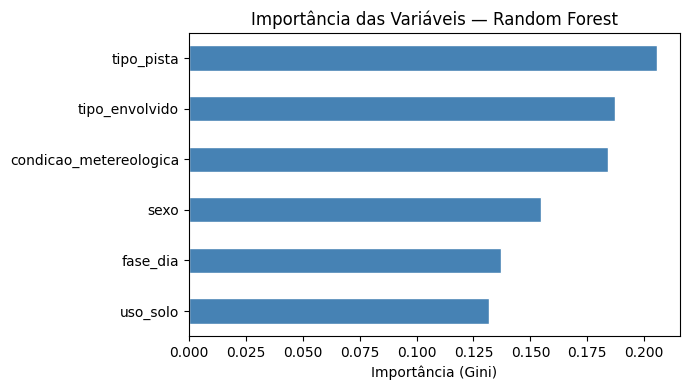

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

features = ["sexo", "tipo_envolvido", "condicao_metereologica",
            "fase_dia", "uso_solo", "tipo_pista"]

imp = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
imp.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Importância (Gini)")
ax.set_title("Importância das Variáveis — Random Forest")
plt.tight_layout()
plt.show()

**tipo_pista (≈ 0.207)** lidera como principal discriminador da gravidade, o que é coerente: pistas simples concentram colisões frontais e sem acostamento, condições estruturalmente mais perigosas.

**tipo_envolvido (≈ 0.187)** e **condicao_metereologica (≈ 0.183)** ficaram praticamente empatados, refletindo que o perfil do envolvido e as condições climáticas contribuem de forma similar para separar as classes.

**sexo (≈ 0.153)** teve importância moderada, provavelmente captando padrões de exposição ao risco diferentes entre homens e mulheres.

**fase_dia (≈ 0.135)** e **uso_solo (≈ 0.132)** fecham o ranking com contribuições menores mas não desprezíveis — parte do sinal deles já é capturado pelas variáveis acima, o que reduz artificialmente sua importância individual no critério de Gini.

De forma geral, a distribuição equilibrada entre as seis variáveis (~13% a ~21%) é um bom sinal: indica que o modelo não está dependendo excessivamente de uma única variável, o que tende a gerar predições mais robustas e generalizáveis.

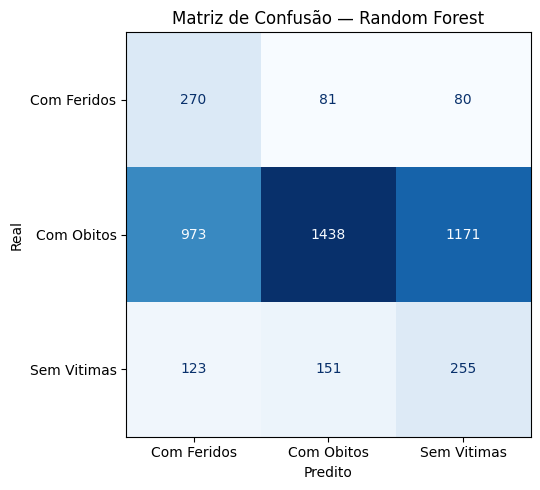

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Com Feridos", "Com Obitos", "Sem Vitimas"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de Confusão — Random Forest")
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

## Resultados

O modelo Random Forest foi aplicado à classificação dos acidentes de trânsito na Paraíba em três categorias: Com Vítimas Fatais, Com Vítimas Feridas e Sem Vítimas, utilizando as variáveis sexo, tipo de envolvido, condição meteorológica, fase do dia, uso do solo e tipo de pista.

O modelo obteve acurácia de 43% e AUC-ROC macro de 0,68. A acurácia baixa é esperada dado o desbalanceamento das classes, sendo o AUC-ROC a métrica mais adequada para avaliação. A classe Com Vítimas Feridas apresentou maior precisão (86%), enquanto Com Vítimas Fatais obteve melhor recall (63%), indicando que o modelo identifica a maioria dos casos fatais, ainda que com elevado número de falsos positivos. A classe Sem Vítimas teve o pior desempenho geral.

Quanto às variáveis explicativas, o tipo de pista foi o fator mais importante para a predição (Gini ≈ 0,207), seguido pelo tipo de envolvido (≈ 0,187) e pela condição meteorológica (≈ 0,183). As demais variáveis contribuíram de forma equilibrada, sem que nenhuma dominasse isoladamente o modelo.